In [106]:
import pandas as pd

df = pd.read_csv("../dataset_with_labels.csv")
df.head()

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,average_song
0,2plbrEY59IikOBgBGLjaoe,Die With A Smile,"Lady Gaga, Bruno Mars",1,1,0,NaN,2025-02-17,98,False,...,-7.777,0,0.0304,0.3080,0.0000,0.122,0.535,157.969,3,Lower
1,2CGNAOSuO1MEFCbBRgUzjd,luther (with sza),"Kendrick Lamar, SZA",2,1,4,NaN,2025-02-17,90,False,...,-7.546,1,0.1250,0.2510,0.0000,0.248,0.576,138.008,4,About_Average
2,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,Kendrick Lamar,3,-2,8,NaN,2025-02-17,92,True,...,-7.001,1,0.0776,0.0107,0.0000,0.141,0.214,101.061,4,Higher
3,4wJ5Qq0jBN4ajy7ouZIV1c,APT.,"ROSÉ, Bruno Mars",4,0,-2,NaN,2025-02-17,89,False,...,-4.477,0,0.2600,0.0283,0.0000,0.355,0.939,149.027,4,Higher
4,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,Billie Eilish,5,1,-2,NaN,2025-02-17,96,False,...,-10.171,1,0.0358,0.2000,0.0608,0.117,0.438,104.978,4,About_Average


In [107]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["spotify_id", "name", "artists", "snapshot_date", "country", "album_name", "album_release_date", "popularity"], axis=1, inplace=False)
y = df["popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

estimator = RidgeClassifier(alpha=250000)
encode = OneHotEncoder()
scaler = MinMaxScaler()


preprocessing = make_column_transformer((encode, ['average_song']), (scaler, ['key', 'daily_rank', 'daily_movement', 'weekly_movement',
       'is_explicit', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'] ), remainder='passthrough')

pipeline = make_pipeline(preprocessing, estimator)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(),
                                                  ['average_song']),
                                                 ('minmaxscaler',
                                                  MinMaxScaler(),
                                                  ['key', 'daily_rank',
                                                   'daily_movement',
                                                   'weekly_movement',
                                                   'is_explicit', 'duration_ms',
                                                   'danceability', 'energy',
                                                   'key', 'loudness', 'mode',
                                                   'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo',
                                                   'time_signature'])])),
                ('ridgeclassifier', RidgeClassifier(alpha=20000))])

In [109]:
import shap as shap

fraction_of_data = 0.5

feature_names = preprocessing.get_feature_names_out()

X_train_transformed = preprocessing.transform(X_train.sample(frac=fraction_of_data))

explainer = shap.Explainer(
    estimator.predict,
    X_train_transformed,
    feature_names=feature_names
)

small = X_test.sample(frac=fraction_of_data)
X_test_transformed = preprocessing.transform(small)
shap_values = explainer(X_test_transformed)

for i, c in enumerate(shap_values.feature_names):
    shap_values.feature_names[i] = c[c.rfind("__") + 2:]
    
    

PermutationExplainer explainer: 172839it [1:00:39, 47.25it/s]                              


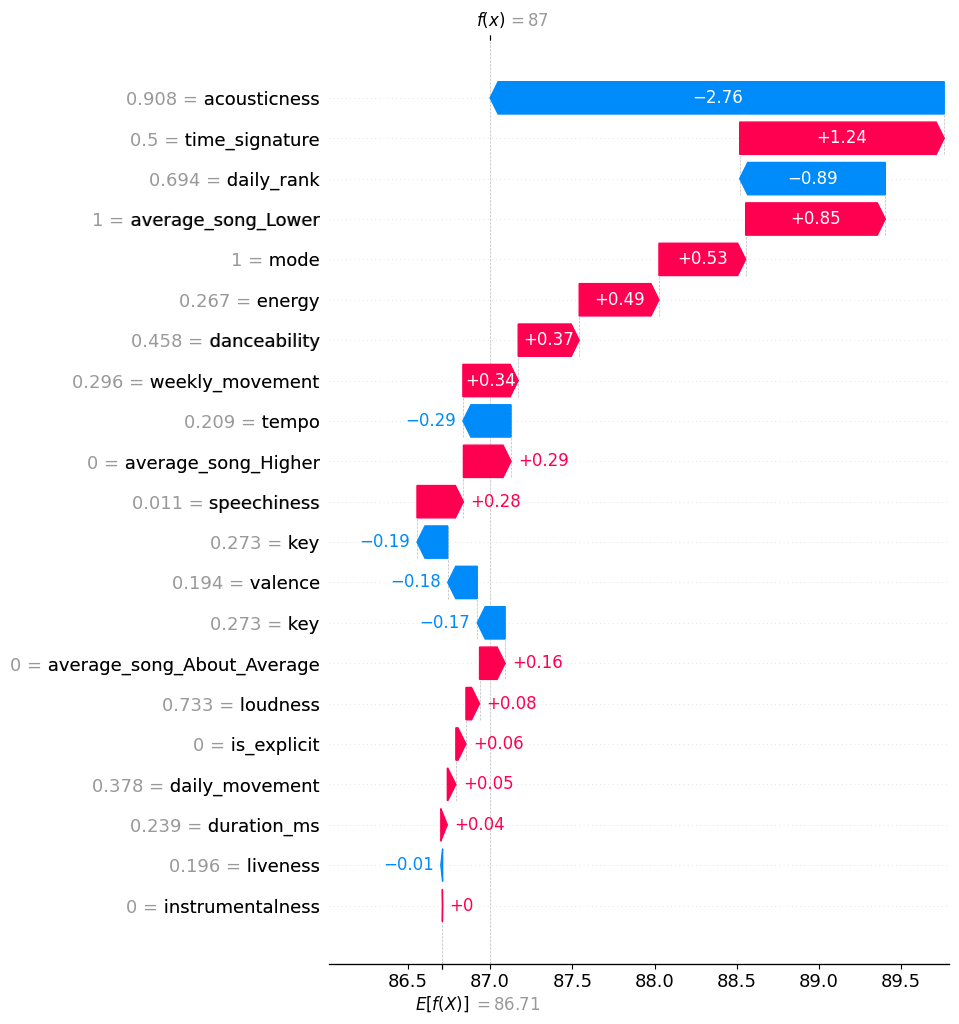

In [110]:
# PLots a single prediction and how it got there
shap.plots.waterfall(shap_values[0], max_display=50)


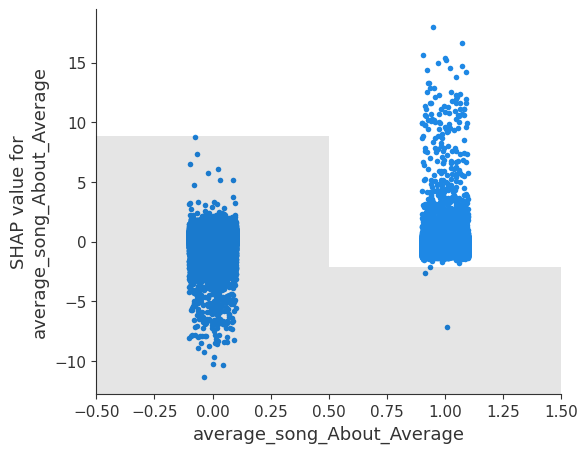

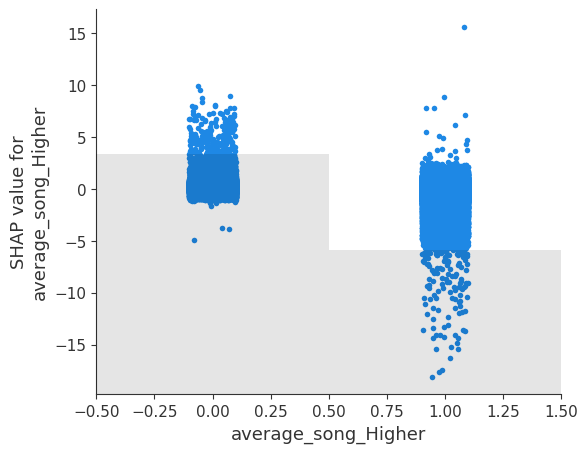

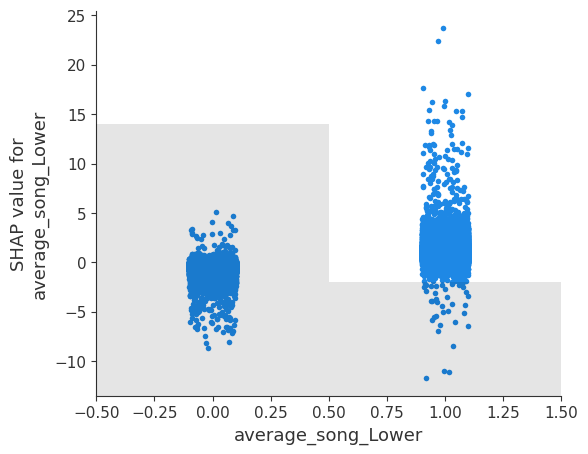

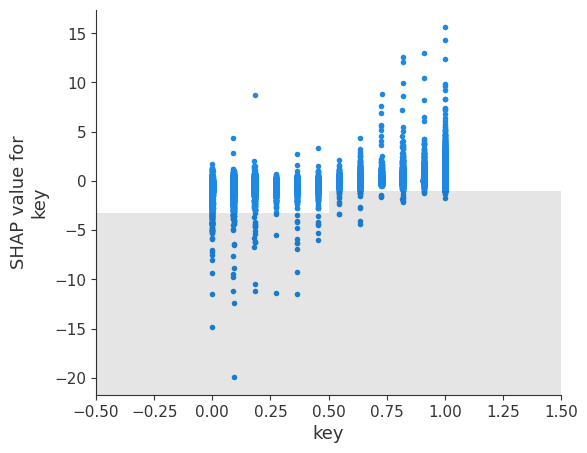

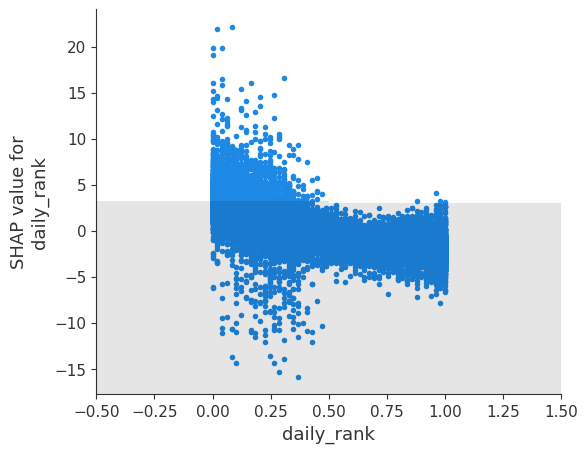

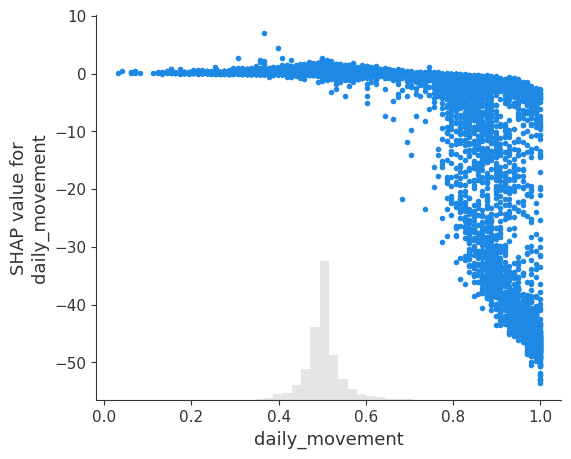

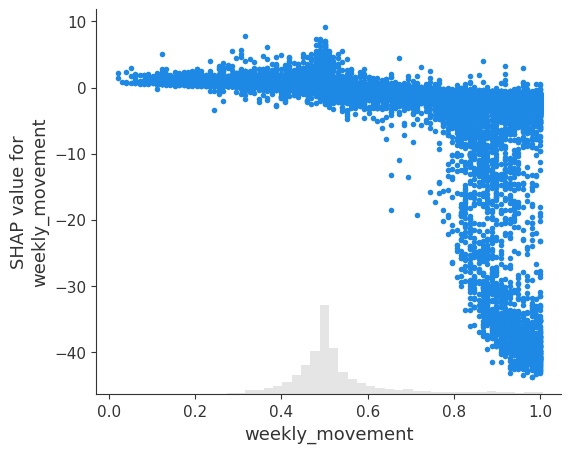

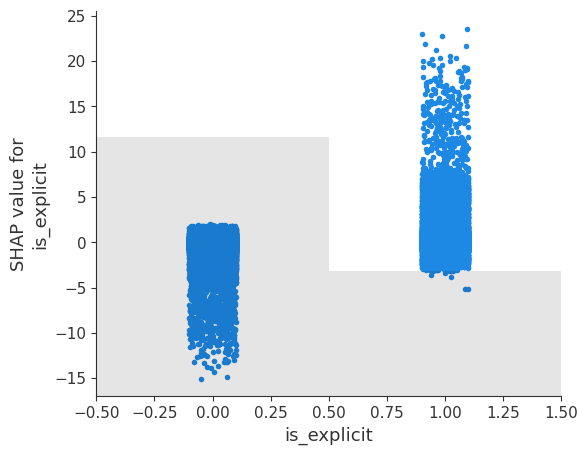

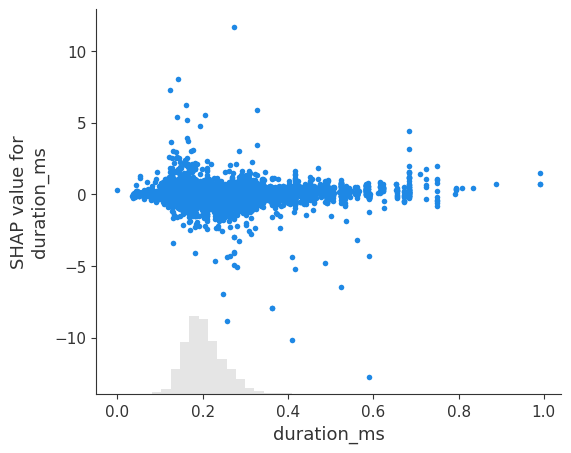

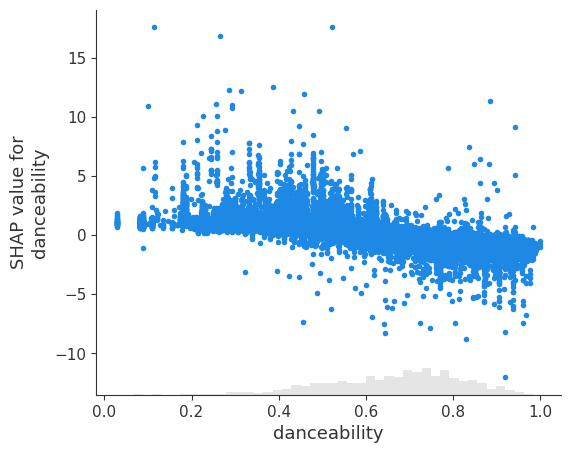

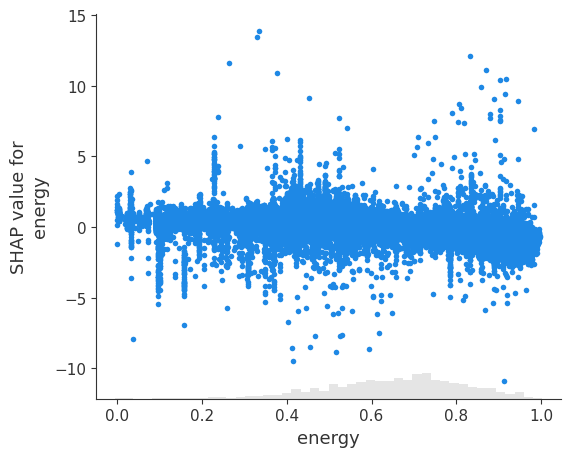

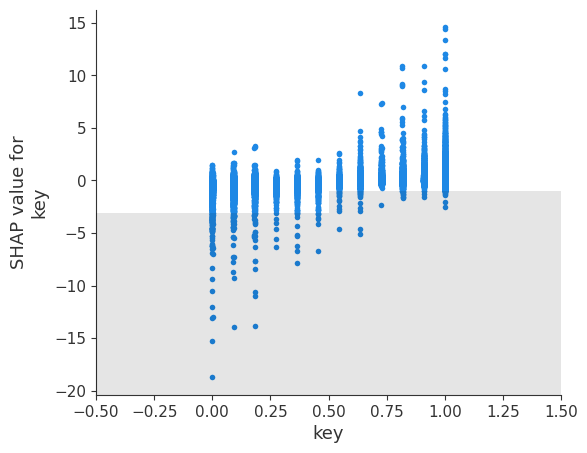

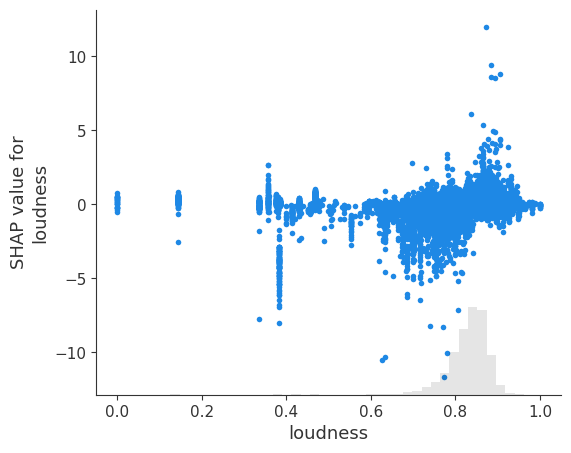

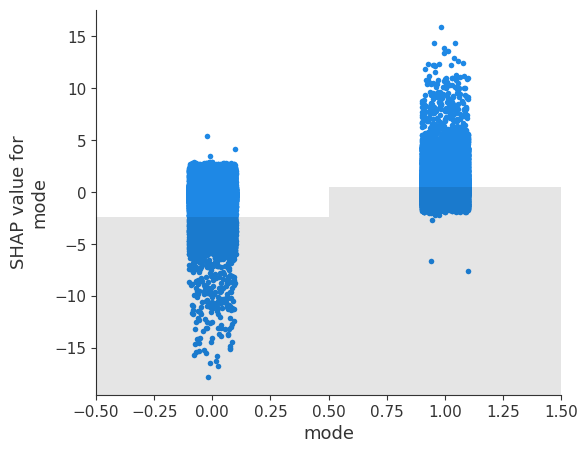

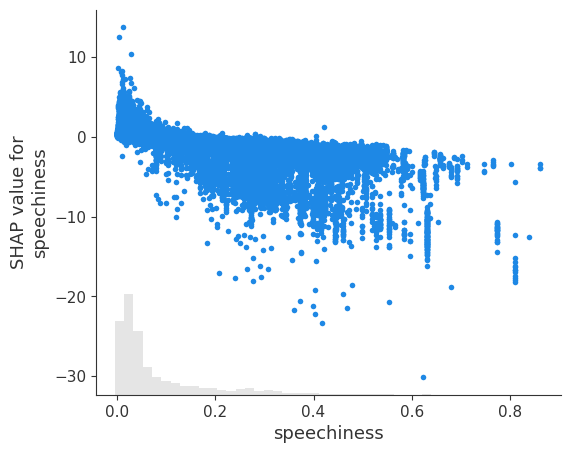

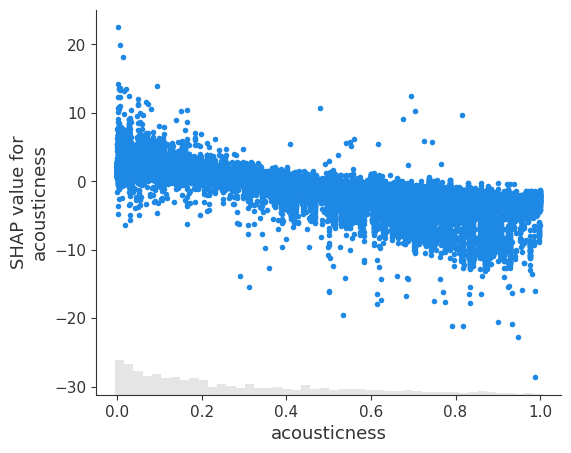

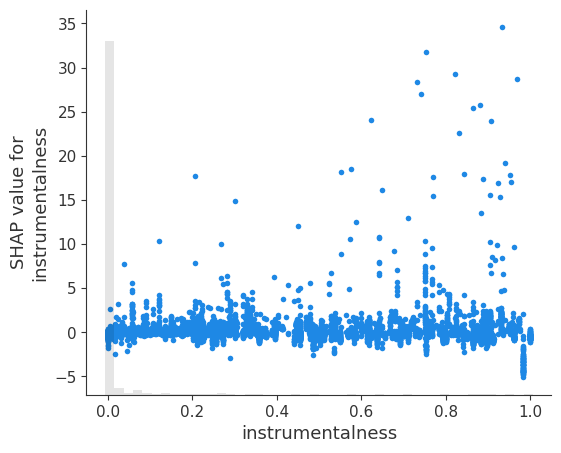

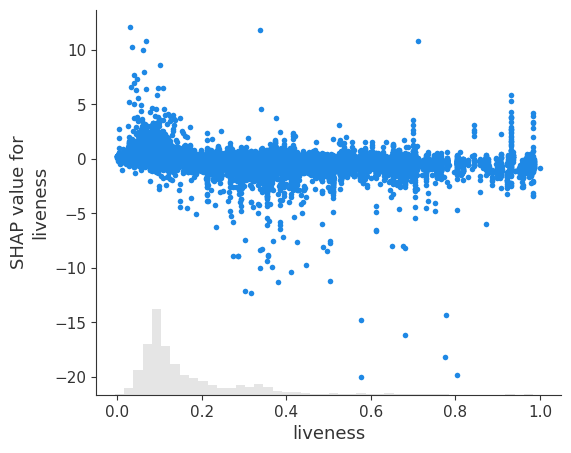

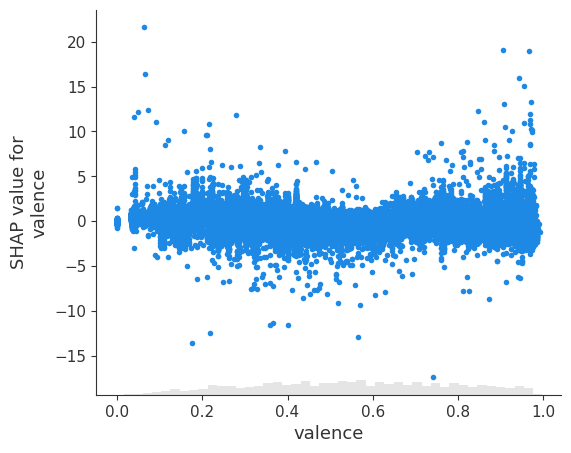

In [111]:
# Plots how each feature affects the model's output
for i in range(0, 19):
    shap.plots.scatter(shap_values[:, i])

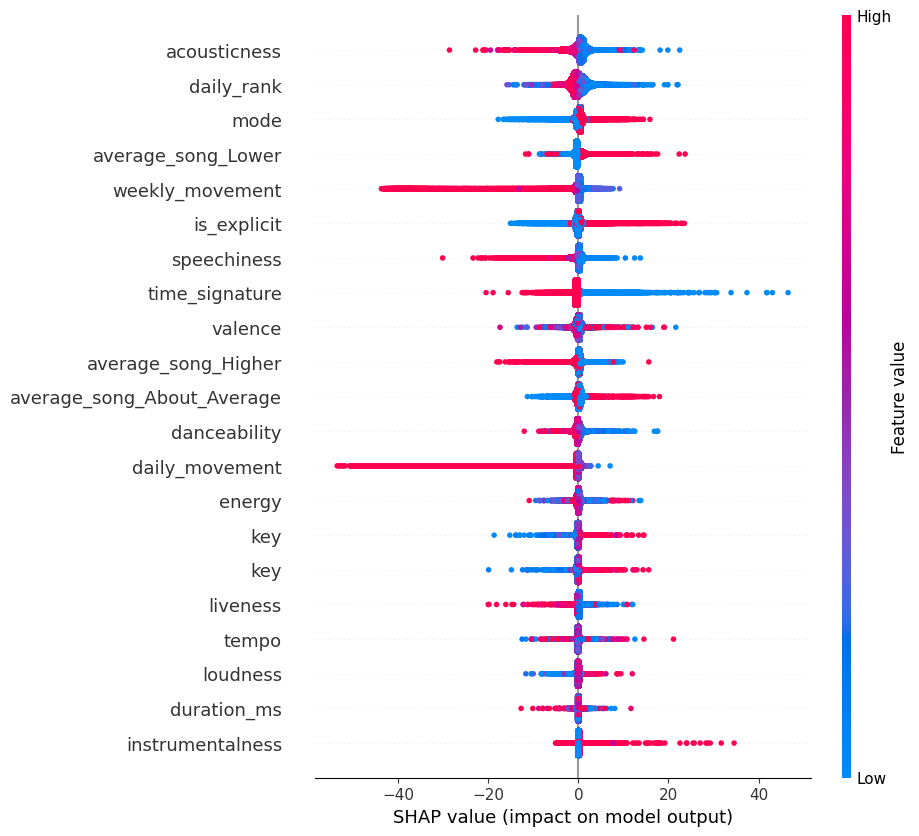

In [112]:
# Plots the summary of the model's predictions
shap.plots.beeswarm(shap_values, max_display=50)

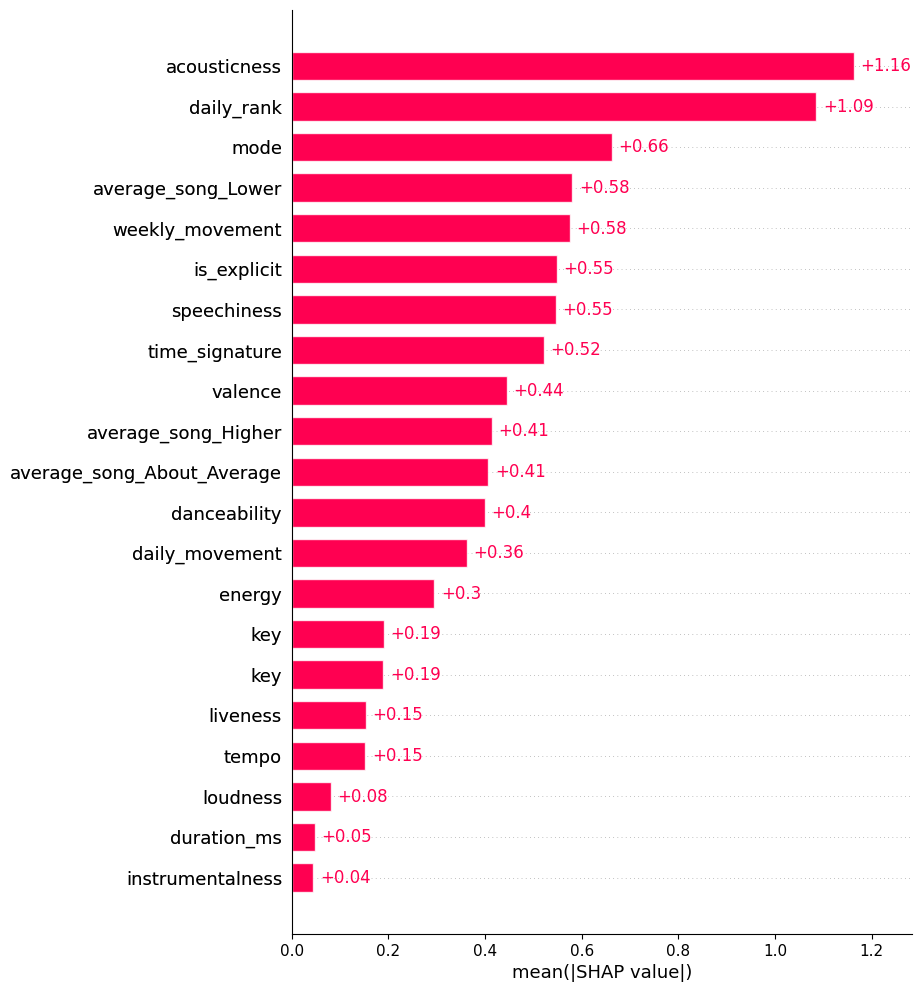

In [113]:
# Bar chart of features that most affect the model's output
shap.plots.bar(shap_values, max_display=50)